# Customer Shopping Behavior Analysis

This project analyzes customer purchasing behavior using Python and Power BI.

## Objectives
- Identify key revenue drivers
- Understand customer demographics
- Analyze product category performance
- Evaluate promotion effectiveness
- Build an interactive Power BI dashboard

## Dataset Overview

The dataset contains customer shopping behavior information including:

- Customer ID
- Age
- Gender
- Product Category
- Purchase Amount
- Review Rating
- Subscription Status
- Payment Method
- Purchase Frequency
- Previous Purchases

The dataset contains **3900 customer transactions**.

### Import Libraries

In [2]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)

sns.set_style("whitegrid")

### Load Dataset

In [4]:
df = pd.read_csv("customer_shopping_behavior.csv")
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


### Data Overview

In [5]:
df.shape

(3900, 18)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3863 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   

In [7]:
df.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3863.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.750065,25.351538
std,1125.977353,15.207589,23.685392,0.716983,14.447125
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.800000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


Observation

Dataset contains 3900 transactions

Contains 18 variables

Data types include numeric and categorical variables

### Data Cleaning

In [12]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ","_").str.replace("(","").str.replace(")","")

In [13]:
df.isnull().sum()

customer_id               0
age                       0
gender                    0
item_purchased            0
category                  0
purchase_amount_usd       0
location                  0
size                      0
color                     0
season                    0
review_rating             0
subscription_status       0
shipping_type             0
discount_applied          0
promo_code_used           0
previous_purchases        0
payment_method            0
frequency_of_purchases    0
dtype: int64

In [14]:
df['review_rating'] = df['review_rating'].fillna(df['review_rating'].mean())

### Exploratory Data Analysis (EDA)

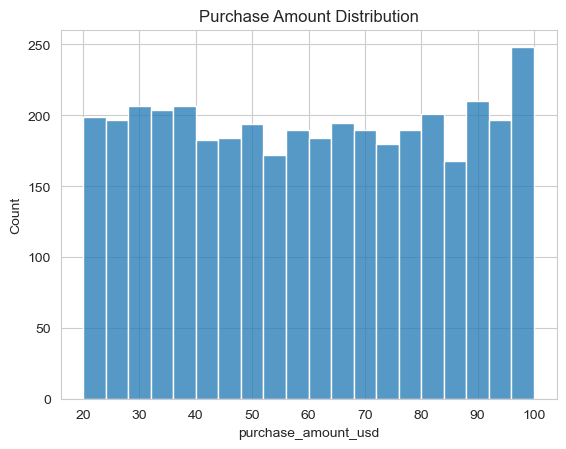

In [17]:
#Purchase Amount Distribution

sns.histplot(df['purchase_amount_usd'], bins=20)
plt.title("Purchase Amount Distribution")
plt.show()

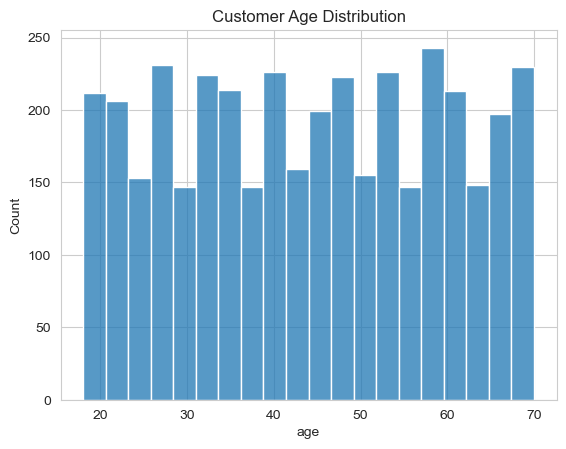

In [18]:
#Age Distribution

sns.histplot(df['age'], bins=20)
plt.title("Customer Age Distribution")
plt.show()

In [19]:
# Age Segmentation

bins = [18,25,35,45,60,100]

labels = [
'Young Adult',
'Adult',
'Middle Age',
'Senior',
'Elder'
]

df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels)

In [20]:
df['age_group'].value_counts()

age_group
Senior         1135
Adult           742
Middle Age      729
Elder           723
Young Adult     502
Name: count, dtype: int64

### KPI 1 — Revenue Analysis

In [21]:
# Total Revenue

total_revenue = df['purchase_amount_usd'].sum()
total_revenue

np.int64(233081)

Observation :

Total revenue generated = $233,081

In [25]:
#Average Order Value

df['purchase_amount_usd'].mean()

np.float64(59.76435897435898)

Observation :

Average spending per purchase ≈ $60

In [26]:
# Revenue by Category

df.groupby('category')['purchase_amount_usd'].sum().sort_values(ascending=False)

category
Clothing       104264
Accessories     74200
Footwear        36093
Outerwear       18524
Name: purchase_amount_usd, dtype: int64

Observation

Clothing generates highest revenue

Revenue difference is driven by purchase volume

### KPI 2 — Customer Demographics

In [28]:
# Spending by Age Group
df.groupby('age_group', observed=True)['purchase_amount_usd'].mean()

age_group
Young Adult    60.739044
Adult          59.760108
Middle Age     59.305898
Senior         59.657269
Elder          59.701245
Name: purchase_amount_usd, dtype: float64

Observation

Average spending is similar across age groups.

Age affects customer volume, not spending per purchase.

In [29]:
# Gender Analysis
df.groupby('gender')['purchase_amount_usd'].mean()

gender
Female    60.249199
Male      59.536199
Name: purchase_amount_usd, dtype: float64

In [30]:
df.groupby('gender')['purchase_amount_usd'].sum()

gender
Female     75191
Male      157890
Name: purchase_amount_usd, dtype: int64

Observation

Spending behavior between genders is relatively similar.

### KPI 3 — Promotion Impact

In [31]:
# Discount Effect
df.groupby('discount_applied')['purchase_amount_usd'].mean()

discount_applied
No     60.130454
Yes    59.279070
Name: purchase_amount_usd, dtype: float64

Observation

Discounts do not significantly increase purchase amount.

In [32]:
# Subscription Impact
df.groupby('subscription_status')['purchase_amount_usd'].mean()

subscription_status
No     59.865121
Yes    59.491928
Name: purchase_amount_usd, dtype: float64

Observation

Subscription customers spend almost the same per purchase.

In [33]:
#Key Findings:

#1. Revenue is primarily volume-driven.
#2. Clothing category contributes the largest share of revenue.
#3. Age affects customer distribution but not spending intensity.
#4. Discounts do not significantly increase purchase value.
#5. Subscription status does not strongly impact spending.